In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pingouin as pg

palette = {
    "gamma1": "#E76F51",
    "gamma2": "#EFAE22",
    "gamma3": "#DCCF67",
    "gamma4": "#95BE56",
    "gamma5": "#4FA9D9",
    "betap2": "#A566A8",
}


# Fig 3d,e

In [2]:
gamma_long_ds = pd.read_csv('gamma1_gamma2_ds10Hz_dff0.csv')
gamma_long_ds

,Genotype,Compartment,Trial,Time_ds,Time,dff0
0,+,gamma1,0,0.0,0.0250,0.016618
1,+,gamma1,0,1.0,0.1000,0.026584
2,+,gamma1,0,2.0,0.2000,0.032407
3,+,gamma1,0,3.0,0.3000,0.046624
4,+,gamma1,0,4.0,0.4000,0.012992
...,...,...,...,...,...,...
1177,Chrimson,gamma2,7,39.0,3.9000,0.056933
1178,Chrimson,gamma2,7,40.0,4.0000,0.094642
1179,Chrimson,gamma2,7,41.0,4.1000,0.109152
1180,Chrimson,gamma2,7,42.0,4.2000,0.115727


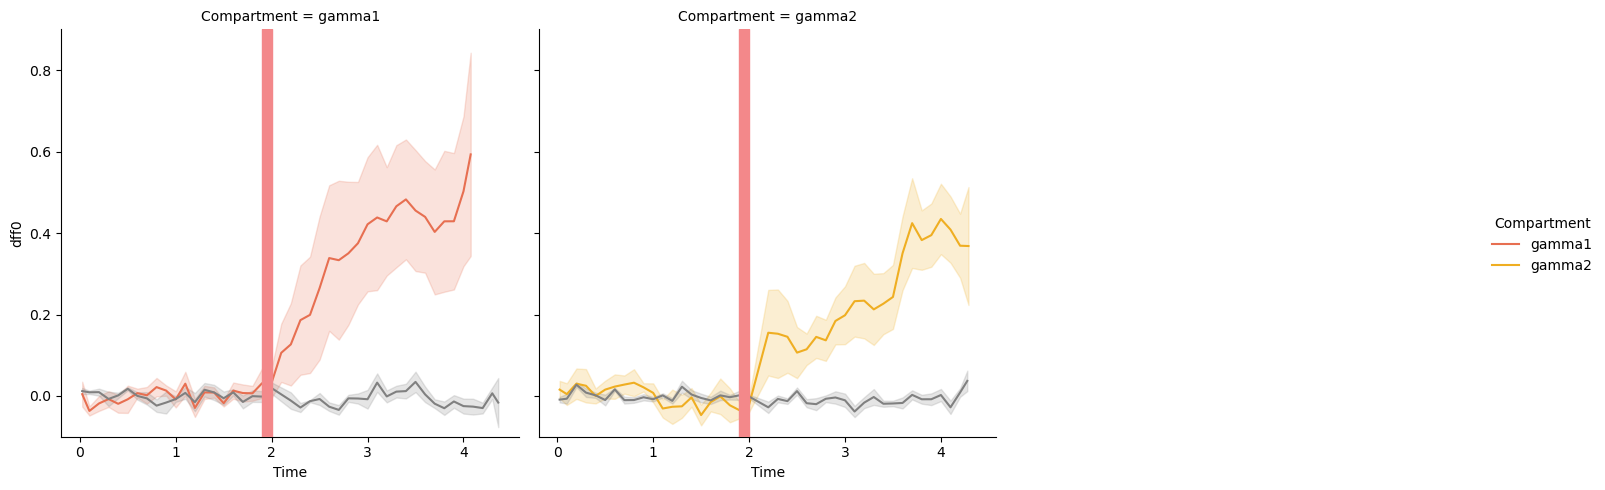

In [3]:
g = sns.relplot(data=gamma_long_ds.query("Genotype == 'Chrimson'"), x='Time', y='dff0', hue='Compartment',
             kind='line', **{'errorbar':'se'}, col='Compartment', col_wrap=3,
             palette=palette)

# overlay '+' as grey
for comp, ax in zip(g.col_names, g.axes.flatten()):
    sns.lineplot(
        data=gamma_long_ds.query("Genotype == '+' and Compartment == @comp"),
        x='Time', y='dff0',
        color='grey',
        errorbar='se',
        ax=ax,
        legend=False
    )

g.set(ylim=(-0.1,0.9));

for ax in g.axes.flatten():
    ax.axvspan(1.9, 2.0, color='#f3888a', alpha=1.0, zorder=10)

In [4]:
gamma_long_ds['prepost'] = np.nan
gamma_long_ds.loc[gamma_long_ds.Time<1.8, 'prepost'] = 'pre'
gamma_long_ds.loc[gamma_long_ds.Time>2.2, 'prepost'] = 'post'
gamma_stats = gamma_long_ds.groupby(['Genotype', 'Compartment', 'Trial', 'prepost']).mean()['dff0'].reset_index()
gamma_stats['prepost'] = pd.Categorical(gamma_stats['prepost'],
                                   categories=['pre', 'post'],
                                   ordered=True)

/var/folders/lr/x3_df06s0z7167lnqf_6s2xh0000gn/T/ipykernel_78589/1839431889.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'pre' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  gamma_long_ds.loc[gamma_long_ds.Time<1.8, 'prepost'] = 'pre'


In [5]:
gamma_stats_delta = gamma_stats.loc[gamma_stats.prepost=='post'].reset_index(drop=True)
gamma_stats_delta['dff0'] -= gamma_stats.loc[gamma_stats.prepost=='pre', 'dff0'].values

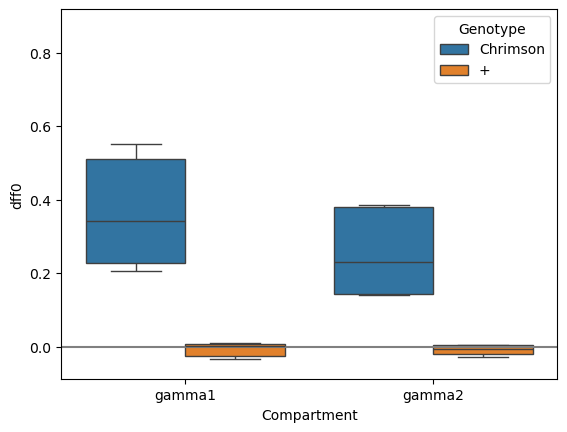

In [6]:
sns.boxplot(data=gamma_stats_delta, x='Compartment', y='dff0', hue='Genotype', fliersize=0, order=['gamma1', 'gamma2'],
            hue_order=['Chrimson', '+'], whis=(10, 90))
plt.axhline(0, color='grey')


In [7]:
pvals_gamma = []
for comp in ['gamma1', 'gamma2']:
    pvals_gamma.append(pg.pairwise_tests(gamma_stats_delta.loc[gamma_stats_delta.Compartment==comp], dv='dff0', between='Genotype',
                               subject='Trial', parametric=False)['p-unc'].values[0])
pd.DataFrame(pg.multicomp(pvals_gamma, method='holm'), columns=['gamma1', 'gamma2'])

,gamma1,gamma2
0,True,True
1,0.004329,0.002892


# Fig 3f

In [8]:
mdn1b_alldans_long_ds = pd.read_csv('mdn1b_alldans_ds10Hz_dff0.csv')
mdn1b_alldans_long_ds

,Genotype,Compartment,Trial,Time_ds,Time,dff0
0,+,betap2,0,0.0,0.025,-0.039270
1,+,betap2,0,1.0,0.100,0.028081
2,+,betap2,0,2.0,0.200,-0.017621
3,+,betap2,0,3.0,0.300,0.067454
4,+,betap2,0,4.0,0.400,-0.015937
...,...,...,...,...,...,...
4703,Chrimson,gamma5,9,39.0,3.900,0.261496
4704,Chrimson,gamma5,9,40.0,4.000,0.202317
4705,Chrimson,gamma5,9,41.0,4.100,0.173044
4706,Chrimson,gamma5,9,42.0,4.200,0.172449


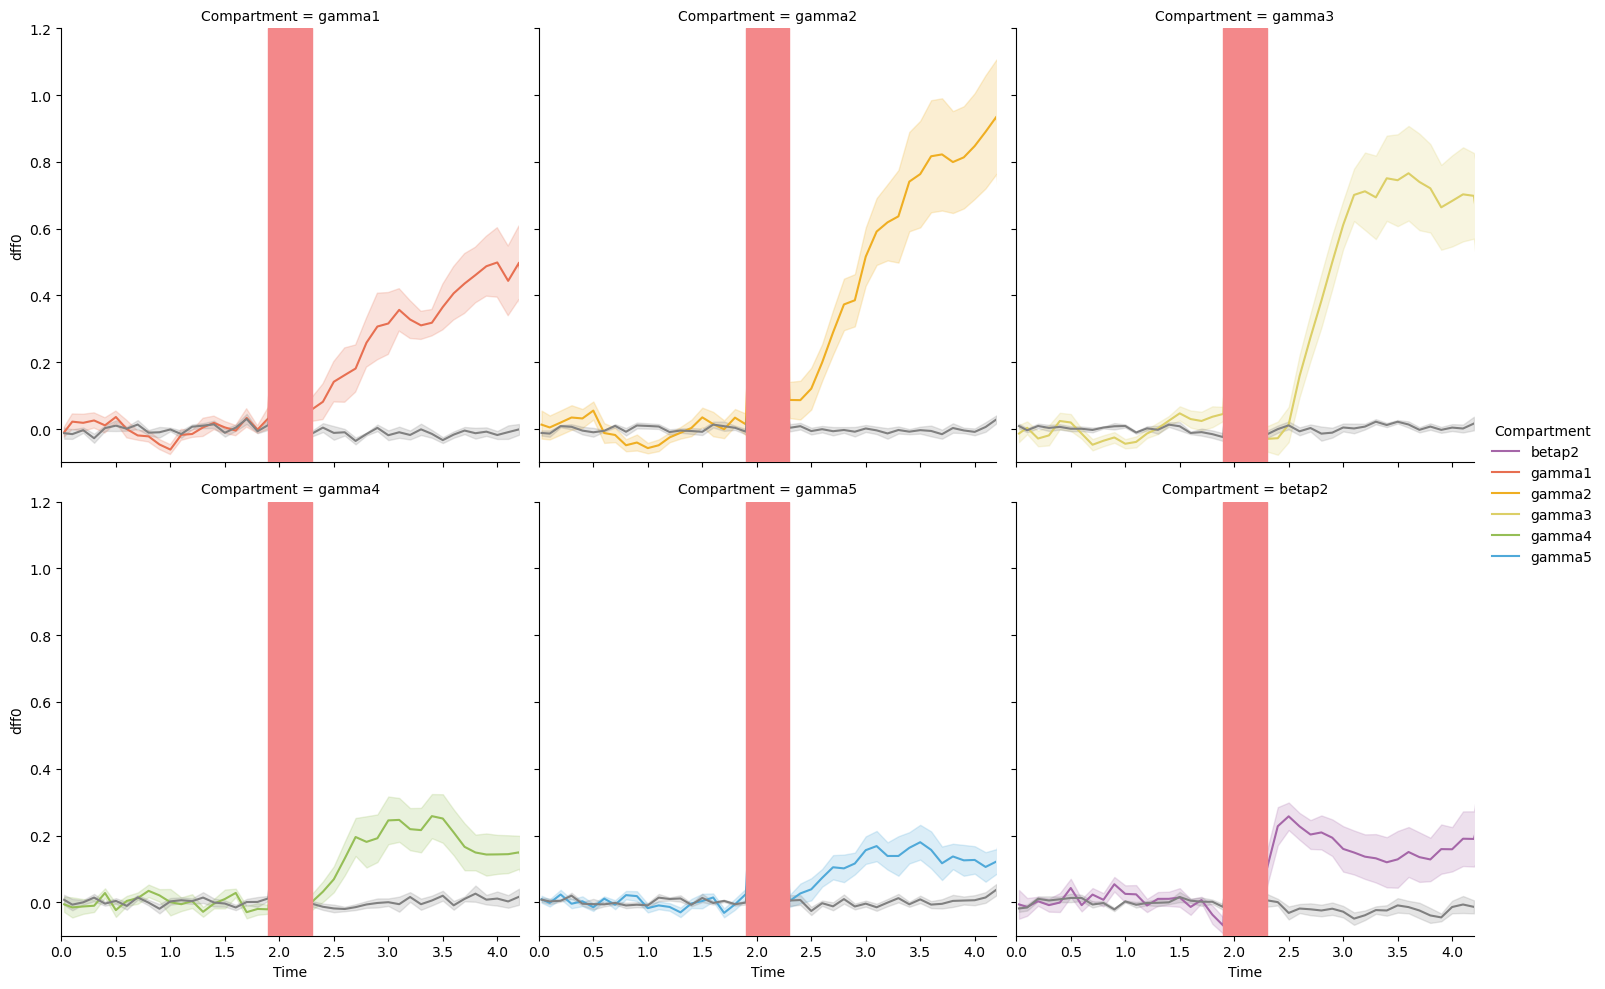

In [9]:
g = sns.relplot(
    data=mdn1b_alldans_long_ds.query("Genotype == 'Chrimson'"),
    x='Time', y='dff0',
    hue='Compartment',
    kind='line', errorbar='se',
    col='Compartment', col_wrap=3,
    col_order=list(palette.keys()),
    palette=palette
)

# overlay '+' as grey
for comp, ax in zip(g.col_names, g.axes.flatten()):
    sns.lineplot(
        data=mdn1b_alldans_long_ds.query("Genotype == '+' and Compartment == @comp"),
        x='Time', y='dff0',
        color='grey',
        errorbar='se',
        ax=ax,
        legend=False
    )

g.set(ylim=(-0.1,1.2), xlim=(0, 4.2))

for ax in g.axes.flatten():
    ax.axvspan(1.9, 2.3, color='#f3888a', alpha=1.0, zorder=10)

In [10]:
mdn1b_alldans_long_ds['prepost'] = np.nan
mdn1b_alldans_long_ds.loc[mdn1b_alldans_long_ds.Time<1.8, 'prepost'] = 'pre'
mdn1b_alldans_long_ds.loc[mdn1b_alldans_long_ds.Time>2.2, 'prepost'] = 'post'
specific_stats = mdn1b_alldans_long_ds.groupby(['Genotype', 'Compartment', 'Trial', 'prepost']).mean()['dff0'].reset_index()
specific_stats['prepost'] = pd.Categorical(specific_stats['prepost'],
                                   categories=['pre', 'post'],
                                   ordered=True)
specific_stats


/var/folders/lr/x3_df06s0z7167lnqf_6s2xh0000gn/T/ipykernel_78589/3315392134.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'pre' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  mdn1b_alldans_long_ds.loc[mdn1b_alldans_long_ds.Time<1.8, 'prepost'] = 'pre'


,Genotype,Compartment,Trial,prepost,dff0
0,+,betap2,0,post,0.044150
1,+,betap2,0,pre,0.000558
2,+,betap2,1,post,-0.104502
3,+,betap2,1,pre,-0.005696
4,+,betap2,2,post,-0.014136
...,...,...,...,...,...
209,Chrimson,gamma5,7,pre,0.002632
210,Chrimson,gamma5,8,post,0.065486
211,Chrimson,gamma5,8,pre,-0.009033
212,Chrimson,gamma5,9,post,0.191296


In [11]:
specific_stats_delta = specific_stats.loc[specific_stats.prepost=='post'].reset_index(drop=True)
specific_stats_delta['dff0'] -= specific_stats.loc[specific_stats.prepost=='pre', 'dff0'].values
specific_stats_delta

,Genotype,Compartment,Trial,prepost,dff0
0,+,betap2,0,post,0.043592
1,+,betap2,1,post,-0.098806
2,+,betap2,2,post,-0.016373
3,+,betap2,3,post,-0.024636
4,+,betap2,4,post,-0.024007
...,...,...,...,...,...
102,Chrimson,gamma5,5,post,0.220878
103,Chrimson,gamma5,6,post,0.011465
104,Chrimson,gamma5,7,post,0.201714
105,Chrimson,gamma5,8,post,0.074519


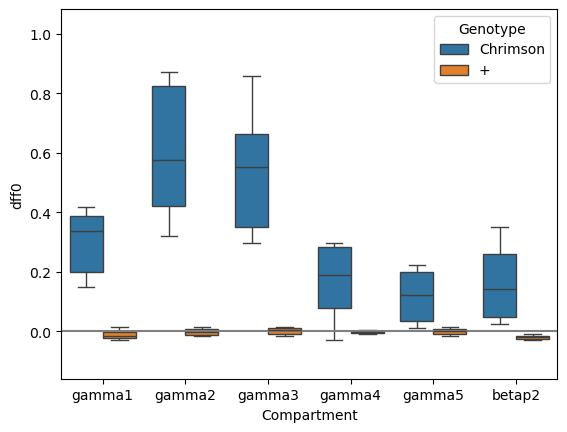

In [12]:
sns.boxplot(data=specific_stats_delta, x='Compartment', y='dff0', hue='Genotype', fliersize=0, order=list(palette.keys()),
            hue_order=['Chrimson', '+'], whis=(10, 90))
plt.axhline(0, color='grey')


In [13]:
pvals_spec = []
for comp in palette.keys():
    pvals_spec.append(pg.pairwise_tests(specific_stats_delta.loc[specific_stats_delta.Compartment==comp], dv='dff0', between='Genotype',
                               subject='Trial', parametric=False)['p-unc'].values[0])
pd.DataFrame(pg.multicomp(pvals_spec, method='holm'), columns=list(palette.keys()))

,gamma1,gamma2,gamma3,gamma4,gamma5,betap2
0,True,True,True,True,True,True
1,0.000274,0.012249,0.000274,0.026647,0.017094,0.016536
